# ChrisCo Data Visualisation Exploration

This notebook compiles the ChrisCo venue datasets into two dataframes:

- **visitor_df**: one row per date, one column per venue (daily visitors).
- **venue_summary_df**: one row per venue, combining visitor-derived metrics with venue attributes.

Each visualisation adapts examples shown in the course material with references to where specifically.

> **NOTE: Data files have been compiled into a single ZIP to make it easier for uploading purposes on Colab.**

## 1. Imports


In [ ]:
# Loads necessary libraries
import os
import zipfile
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import ipywidgets as widgets
from IPython.display import display, clear_output
from google.colab import files, drive

# Ensures pandas dataframes displays all horizontal columns (useful in large datasets)
pd.set_option("display.max_columns", 200)

## 2. Upload and extract data

Mounted Google Drive, then uploaded the ZIP file
containing all six CSVs. This was done to ensure the ZIP doesn't timeout with  the session.


In [ ]:
drive.mount('/content/drive')

uploaded  = files.upload()
ZIP_PATH  = list(uploaded.keys())[0]

EXTRACT_DIR = "chrisco_data"
os.makedirs(EXTRACT_DIR, exist_ok=True)
with zipfile.ZipFile(ZIP_PATH, "r") as z:
    z.extractall(EXTRACT_DIR)

print("Extracted:", sorted(os.listdir(EXTRACT_DIR)))

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Saving Data Visualisation.zip to Data Visualisation.zip
Extracted: ['VenueAge.csv', 'VenueDailyVisitors.csv', 'VenueDistance.csv', 'VenueDuration.csv', 'VenueGender.csv', 'VenueSpend.csv']


## 3. `visitor_df` — one row per date

The index is converted to datetime objects (following `04Data.py`, Lecture 1).
A **Total** column (sum of all venues for each date) is inserted at position 0.

In [ ]:
dv_path = os.path.join(EXTRACT_DIR, "VenueDailyVisitors.csv")
visitor_df = pd.read_csv(dv_path, index_col=0)
visitor_df.index = pd.to_datetime(visitor_df.index)
visitor_df = visitor_df.sort_index()

visitor_df.insert(0, "Total", visitor_df.sum(axis=1))

print("visitor_df shape:", visitor_df.shape) # 365 rows shows a full year of data, 36 columns is the 35 venues + the "Total" column inserted at 0
visitor_df.head()

visitor_df shape: (365, 36)


,Total,NRB,LLJ,VXB,LXE,MFY,ULW,KLZ,MXL,TDE,WJG,OFF,KFO,WRQ,YRY,UXT,VUJ,SXK,PFN,RDX,QXC,VAU,NLQ,QRS,PRK,TLP,PLY,URJ,LRT,VDM,RLH,UOR,OXV,SRZ,XXJ,XDV
Date,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2023-01-01,5653,0,0,71,51,192,50,0,0,87,82,236,0,68,78,75,630,76,552,65,297,628,202,276,245,89,293,59,0,74,68,650,206,95,75,83
2023-01-02,4985,0,0,86,59,178,73,0,0,113,92,240,0,47,83,64,521,94,478,69,169,471,221,252,218,79,225,88,0,67,55,506,167,87,77,106
2023-01-03,4644,0,0,77,72,127,74,0,0,39,98,151,0,65,78,72,298,87,402,60,209,563,199,221,147,86,313,74,0,95,58,545,167,100,83,84
2023-01-04,3816,0,0,100,39,87,71,0,0,83,87,126,0,56,83,64,450,90,332,84,178,338,112,185,115,66,175,68,0,74,59,347,77,107,66,97
2023-01-05,4060,0,0,85,60,92,67,0,0,83,88,152,0,51,76,57,470,106,302,71,228,329,141,189,118,106,213,85,0,72,56,423,126,78,73,63


## 4. `venue_summary_df` — one row per venue

Calculated visitor statistics for 35 venues and flagged openings/closings using a 14-day boundary threshold. Merged the five resulting attribute CSVs into a final dataset.

In [ ]:
# Removes the 'Total' column and identifies the year's date range
daily = visitor_df.drop(columns=["Total"])
start_date = daily.index.min()
end_date = daily.index.max()

# Counts outlier days (values > 3 standard deviations from the mean)
def anomaly_count(series):
    std = series.std()
    if std == 0:
        return 0
    return int(((series - series.mean()).abs() / std > 3).sum())
# Loops through each venue to calculate activity, lifecycle flags, and statistics
rows = []
for venue in daily.columns:
    ser         = daily[venue]
    active      = ser > 0
    active_days = int(active.sum())
    # Identifies first/last active dates and set 'Opened' or 'Closed' flags if within 14-day boundaries
    first       = ser[active].index.min() if active_days else pd.NaT
    last        = ser[active].index.max() if active_days else pd.NaT
    opened = bool(pd.notna(first) and first > start_date + pd.Timedelta(days=14))
    closed = bool(pd.notna(last)  and last  < end_date   - pd.Timedelta(days=14))
    rows.append({
        "Venue":              venue,
        "TotalVisitors":      int(ser.sum()),
        "MeanDaily":          round(float(ser.mean()), 1),
        "MedianDaily":        round(float(ser.median()), 1),
        "StdDaily":           round(float(ser.std()), 1),
        "ActiveDays":         active_days,
        "FirstActive":        first,
        "LastActive":         last,
        "OpenedDuringPeriod": opened,
        "ClosedDuringPeriod": closed,
        "AnomalyDays":        anomaly_count(ser),
    })
# Create the summary table and merges 5 additional attribute CSVs (Age, Spend, etc.)
venue_summary_df = pd.DataFrame(rows).set_index("Venue")

for fname in ["VenueAge.csv", "VenueDistance.csv", "VenueDuration.csv",
              "VenueGender.csv", "VenueSpend.csv"]:
    attr = pd.read_csv(os.path.join(EXTRACT_DIR, fname)).set_index("Id")
    venue_summary_df[attr.columns[0]] = attr[attr.columns[0]]

print("venue_summary_df shape:", venue_summary_df.shape)
venue_summary_df.head()

venue_summary_df shape: (35, 15)


,TotalVisitors,MeanDaily,MedianDaily,StdDaily,ActiveDays,FirstActive,LastActive,OpenedDuringPeriod,ClosedDuringPeriod,AnomalyDays,Avg age (yrs),Max travel distance (mls),Avg visit duration (mins),Proportion Female (%),Avg spend (£)
Venue,,,,,,,,,,,,,,,
NRB,8989,24.6,0.0,35.1,164,2023-07-01,2023-12-31,True,False,4,31,3,124,52,11
LLJ,5281,14.5,0.0,35.7,73,2023-10-01,2023-12-30,True,False,8,21,2,93,56,15
VXB,32319,88.5,89.0,10.7,365,2023-01-01,2023-12-31,False,False,0,23,4,98,53,15
LXE,10546,28.9,0.0,30.2,181,2023-01-01,2023-06-30,False,True,0,43,2,90,47,21
MFY,50427,138.2,130.0,35.4,365,2023-01-01,2023-12-31,False,False,0,45,13,88,52,30


## 5. Volume segmentation

### Step 1 — Inspect sorted totals

The cell below prints every venue's total visitor count, largest first.


> **NOTE: The thresholds were chosen by visual inspection of the sorted**
> **totals.**


In [ ]:
totals_sorted = daily.sum().sort_values(ascending=False)
print("Total visitors per venue (sorted highest to lowest):")
print()
print(totals_sorted.to_string())

Total visitors per venue (sorted highest to lowest):

UOR    190593
VUJ    177195
VAU    172012
PFN    160518
PLY     96959
QRS     84922
QXC     77878
OFF     76651
NLQ     65188
PRK     59234
OXV     56453
MFY     50427
SRZ     34764
WJG     33583
VXB     32319
SXK     32274
TDE     31569
TLP     31399
YRY     28834
XXJ     27560
URJ     27473
VDM     25918
UXT     24975
ULW     24772
RDX     23716
RLH     21600
WRQ     21169
XDV     17473
MXL     13708
LRT     11806
LXE     10546
KLZ      9719
NRB      8989
LLJ      5281
KFO      4948


### Step 2 — Define thresholds from the observed breaks

Identified distinct breaks in the distribution; especially after rank 4 and rank 12. Established thresholds ranging from "Very High" ≥ 150,000 to "Very Low" < 10,000. These thresholds are fed into the allocation loop from L02 `06BarChart automatic.py`.

In [ ]:
# Thresholds chosen from visual inspection above
segment_limits = {
    0:       "Very Low",
    10_000:  "Low",
    20_000:  "Medium",
    45_000:  "High",
    150_000: "Very High",
}

# Allocate venues to segments (L02 06BarChart automatic.py pattern)
segments = {}
limits = list(segment_limits.keys())
for i in range(len(limits)):
    if i < len(limits) - 1:
        included = (limits[i] <= daily.sum()) & (daily.sum() < limits[i + 1])
    else:
        included = limits[i] <= daily.sum()
    seg_name = segment_limits[limits[i]]
    segments[seg_name] = list(daily.columns[included])

# Add segment column to summary dataframe
venue_summary_df["VolumeSegment"] = venue_summary_df["TotalVisitors"].apply(
    lambda t: next(s for lim, s in sorted(segment_limits.items(), reverse=True) if t >= lim)
)

for seg in reversed(segments):
    print(f"{seg:10s} ({len(segments[seg]):2d} venues): {segments[seg]}")

Very High  ( 4 venues): ['VUJ', 'PFN', 'VAU', 'UOR']
High       ( 8 venues): ['MFY', 'OFF', 'QXC', 'NLQ', 'QRS', 'PRK', 'PLY', 'OXV']
Medium     (15 venues): ['VXB', 'ULW', 'TDE', 'WJG', 'WRQ', 'YRY', 'UXT', 'SXK', 'RDX', 'TLP', 'URJ', 'VDM', 'RLH', 'SRZ', 'XXJ']
Low        ( 4 venues): ['LXE', 'MXL', 'LRT', 'XDV']
Very Low   ( 4 venues): ['NRB', 'LLJ', 'KLZ', 'KFO']


In [ ]:
# Shared colour palette which is reused across all figures
seg_colours = {
    "Very High": "tab:green",
    "High":      "tab:blue",
    "Medium":    "tab:orange",
    "Low":       "tab:red",
    "Very Low":  "tab:gray",
}

## Figure 1 — Total visitors per venue, sorted and colour-coded by segment

**Lecture examples:** L02 `08BarChart all sorted.py`, `07BarChart all coloured.py`, `09BarChart grouped.py`

Individual bars for Very High, High and Medium venues; Low and Very Low venues are grouped into a single summary bar following the grouping technique from `09BarChart grouped.py`.

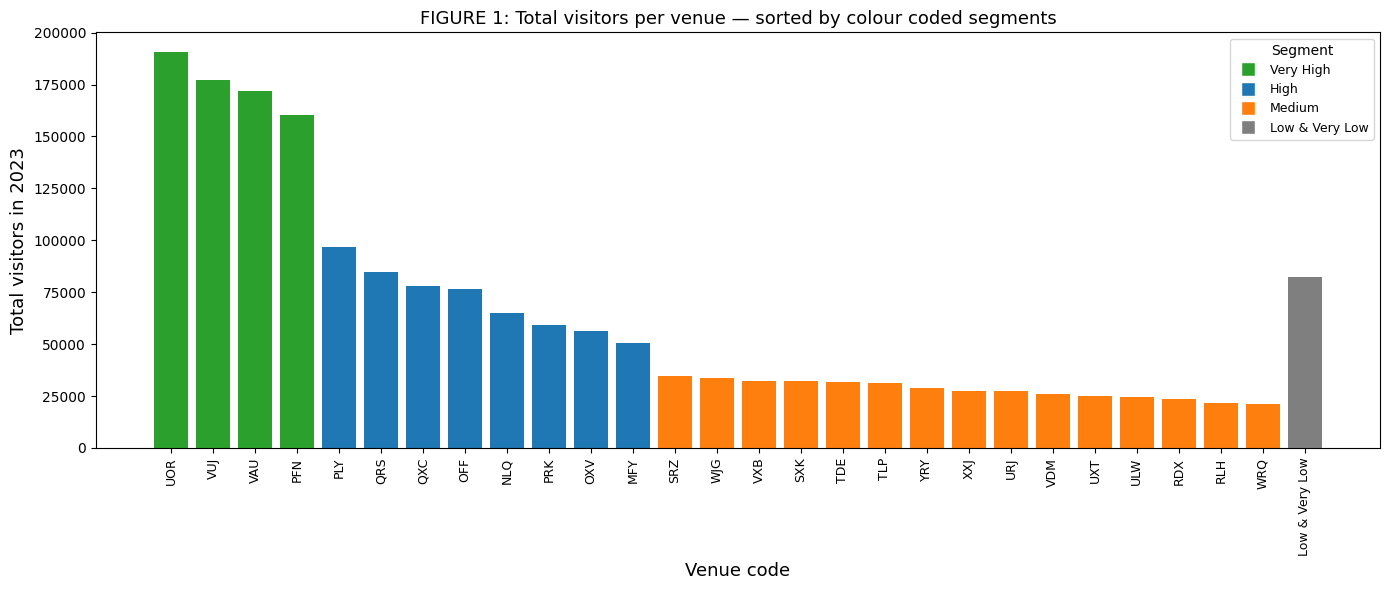

In [ ]:
# Group Low + Very Low into a single summary bar (L02 09BarChart grouped.py pattern)
keep_segments = {"Very High", "High", "Medium"}

selected = []
others_total_series = pd.Series(0, index=daily.index)

for venue in totals_sorted.index:
    seg = venue_summary_df.loc[venue, "VolumeSegment"]
    if seg in keep_segments:
        selected.append(venue)
    else:
        others_total_series += daily[venue]

# Build plot data
plot_venues = selected + ["Low & Very Low"]
plot_values = [daily[v].sum() for v in selected] + [others_total_series.sum()]
plot_colours = [seg_colours[venue_summary_df.loc[v, "VolumeSegment"]]
                for v in selected] + ["tab:gray"]

plt.figure(figsize=(14, 6))
x_pos = np.arange(len(plot_venues))
plt.bar(x_pos, plot_values, color=plot_colours, align="center")
plt.xticks(x_pos, plot_venues, rotation=90, fontsize=9)
plt.xlabel("Venue code", fontsize=13)
plt.ylabel("Total visitors in 2023", fontsize=13)
plt.title("FIGURE 1: Total visitors per venue — sorted by colour coded segments", fontsize=13)

handles = [plt.Line2D([0], [0], marker="s", color="w",
           markerfacecolor=seg_colours[s], markersize=10, label=s)
           for s in ["Very High", "High", "Medium"]] + [
           plt.Line2D([0], [0], marker="s", color="w",
           markerfacecolor="tab:gray", markersize=10, label="Low & Very Low")]
plt.legend(handles=handles, title="Segment", loc="upper right", fontsize=9)
plt.tight_layout()
plt.show()

## Figure 2 — Very-high and high-volume venues over time (7-day rolling average)


**Lecture example:** L03 `05LinePlot high volume rolling averaged.py`

Two subplots sharing the same x-axis, one per segment. Each thin line is one venue's daily visitor count; the thick line in the same colour is its 7-day rolling mean, calculated with `data.rolling(window=period).mean()` and overlaid using `set_prop_cycle(None)`.

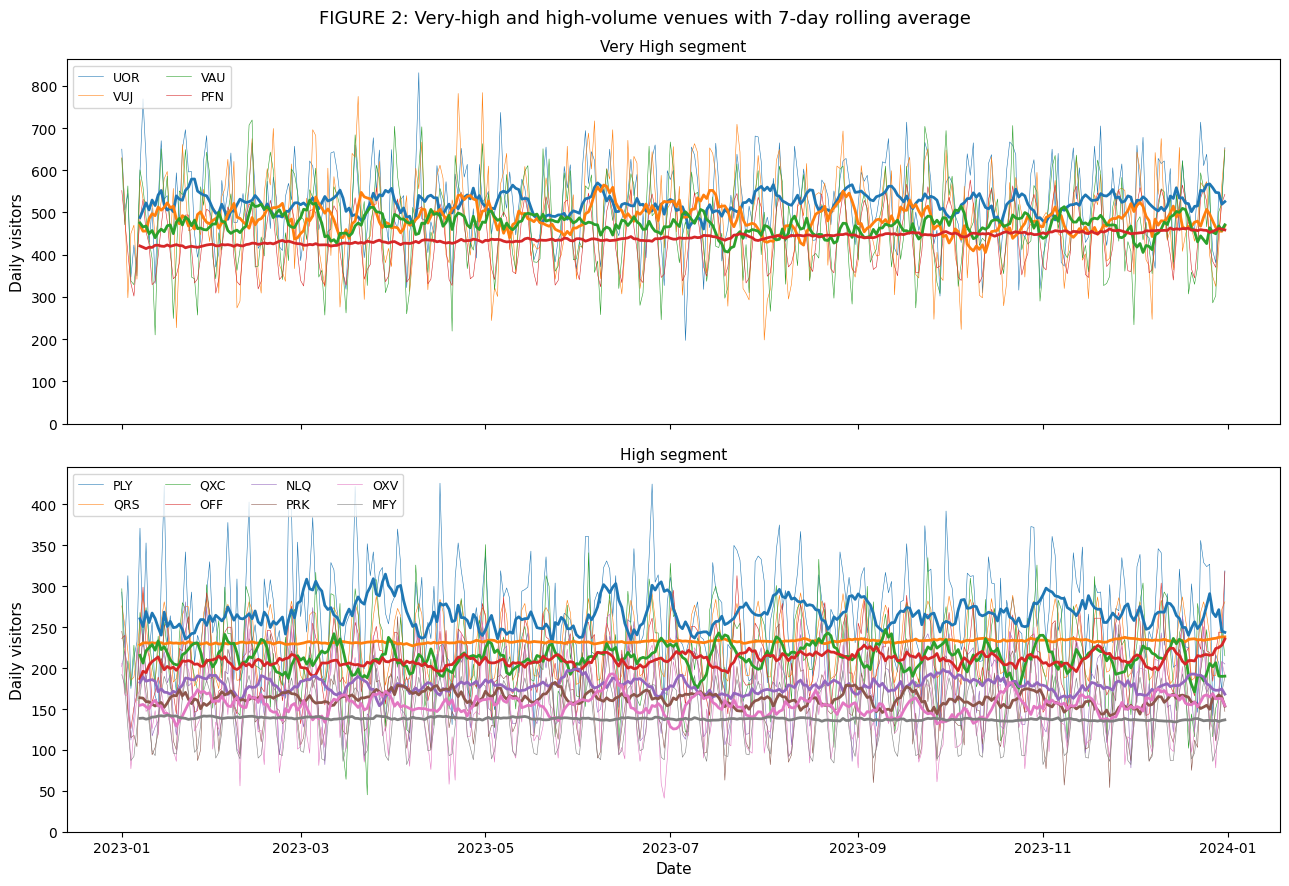

In [ ]:
period   = 7
roll_avg = daily.rolling(window=period).mean()

very_high_venues = sorted(segments["Very High"], key=lambda v: venue_summary_df.loc[v, "TotalVisitors"], reverse=True)
high_venues = sorted(segments["High"],key=lambda v: venue_summary_df.loc[v, "TotalVisitors"], reverse=True)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(13, 9), sharex=True)
fig.suptitle(f"FIGURE 2: Very-high and high-volume venues with {period}-day rolling average",fontsize=13,)

# Very High segment
ax1.plot(daily[very_high_venues], linewidth=0.4)
ax1.set_prop_cycle(None)
ax1.plot(roll_avg[very_high_venues], linewidth=2)
ax1.set_ylim(ymin=0)
ax1.set_ylabel("Daily visitors", fontsize=11)
ax1.set_title("Very High segment", fontsize=11)
ax1.legend(very_high_venues, loc="upper left", ncol=2, fontsize=9)

# High segment
ax2.plot(daily[high_venues], linewidth=0.4)
ax2.set_prop_cycle(None)
ax2.plot(roll_avg[high_venues], linewidth=2)
ax2.set_ylim(ymin=0)
ax2.set_xlabel("Date", fontsize=11)
ax2.set_ylabel("Daily visitors", fontsize=11)
ax2.set_title("High segment", fontsize=11)
ax2.legend(high_venues, loc="upper left", ncol=4, fontsize=9)

plt.tight_layout()
plt.show()

## Figure 3 — Composition of daily visitors over time (stacked area)

**Lecture examples:** L03 `14AreaPlot all sorted.py`, L02 `09BarChart grouped.py`

Data sorted highest-to-lowest before stacking (`14AreaPlot all sorted.py`). The bottom 27 venues are aggregated into an **Others** band using the grouping technique from `09BarChart grouped.py`.

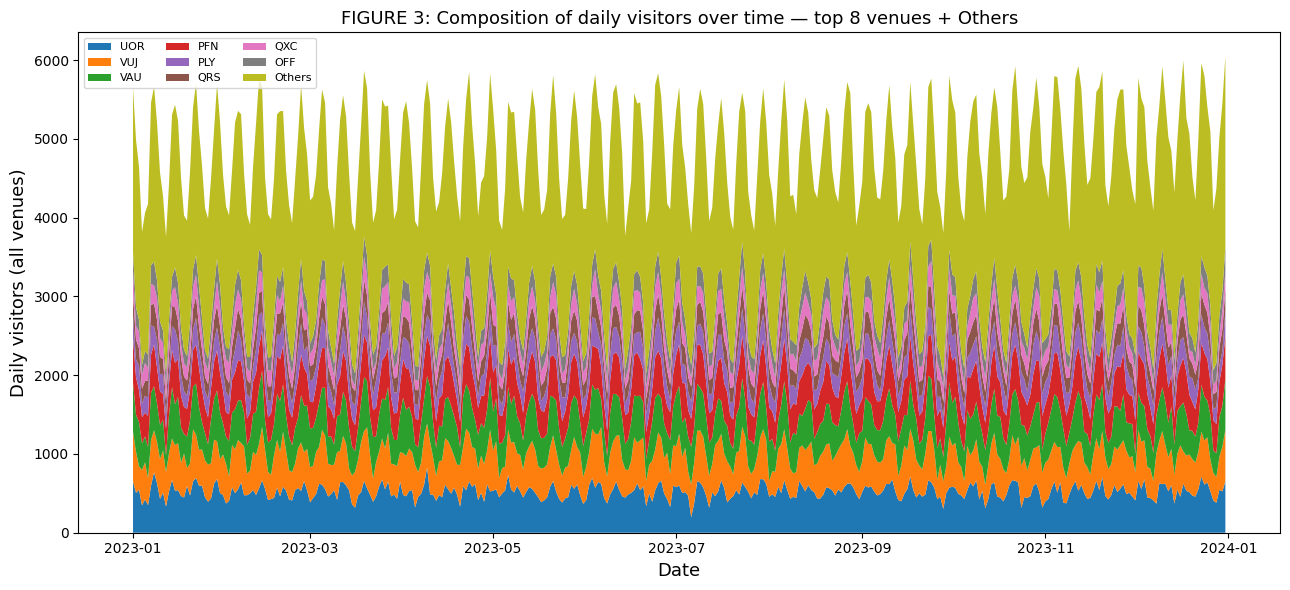

In [ ]:
top8 = totals_sorted.index[:8].tolist()

df_area          = daily[top8].copy()
df_area["Others"] = daily.drop(columns=top8).sum(axis=1)

plt.figure(figsize=(13, 6))
plt.stackplot(df_area.index, df_area[top8 + ["Others"]].T)
plt.xlabel("Date", fontsize=13)
plt.ylabel("Daily visitors (all venues)", fontsize=13)
plt.title("FIGURE 3: Composition of daily visitors over time — top 8 venues + Others",fontsize=13,)
plt.legend(top8 + ["Others"], loc="upper left", ncol=3, fontsize=8)
plt.tight_layout()
plt.show()

## Figure 4 — Autocorrelation plots: detecting seasonal patterns

**Lecture examples:** L05 `10Autocorrelation all.py`, `11Autocorrelation selected.py`

Uses `pd.plotting.autocorrelation_plot()` in the same row/column grid loop as `10Autocorrelation all.py`. The x-axis is limited to lags 0–60 so weekly peaks at 7, 14, 21… days are clearly visible.

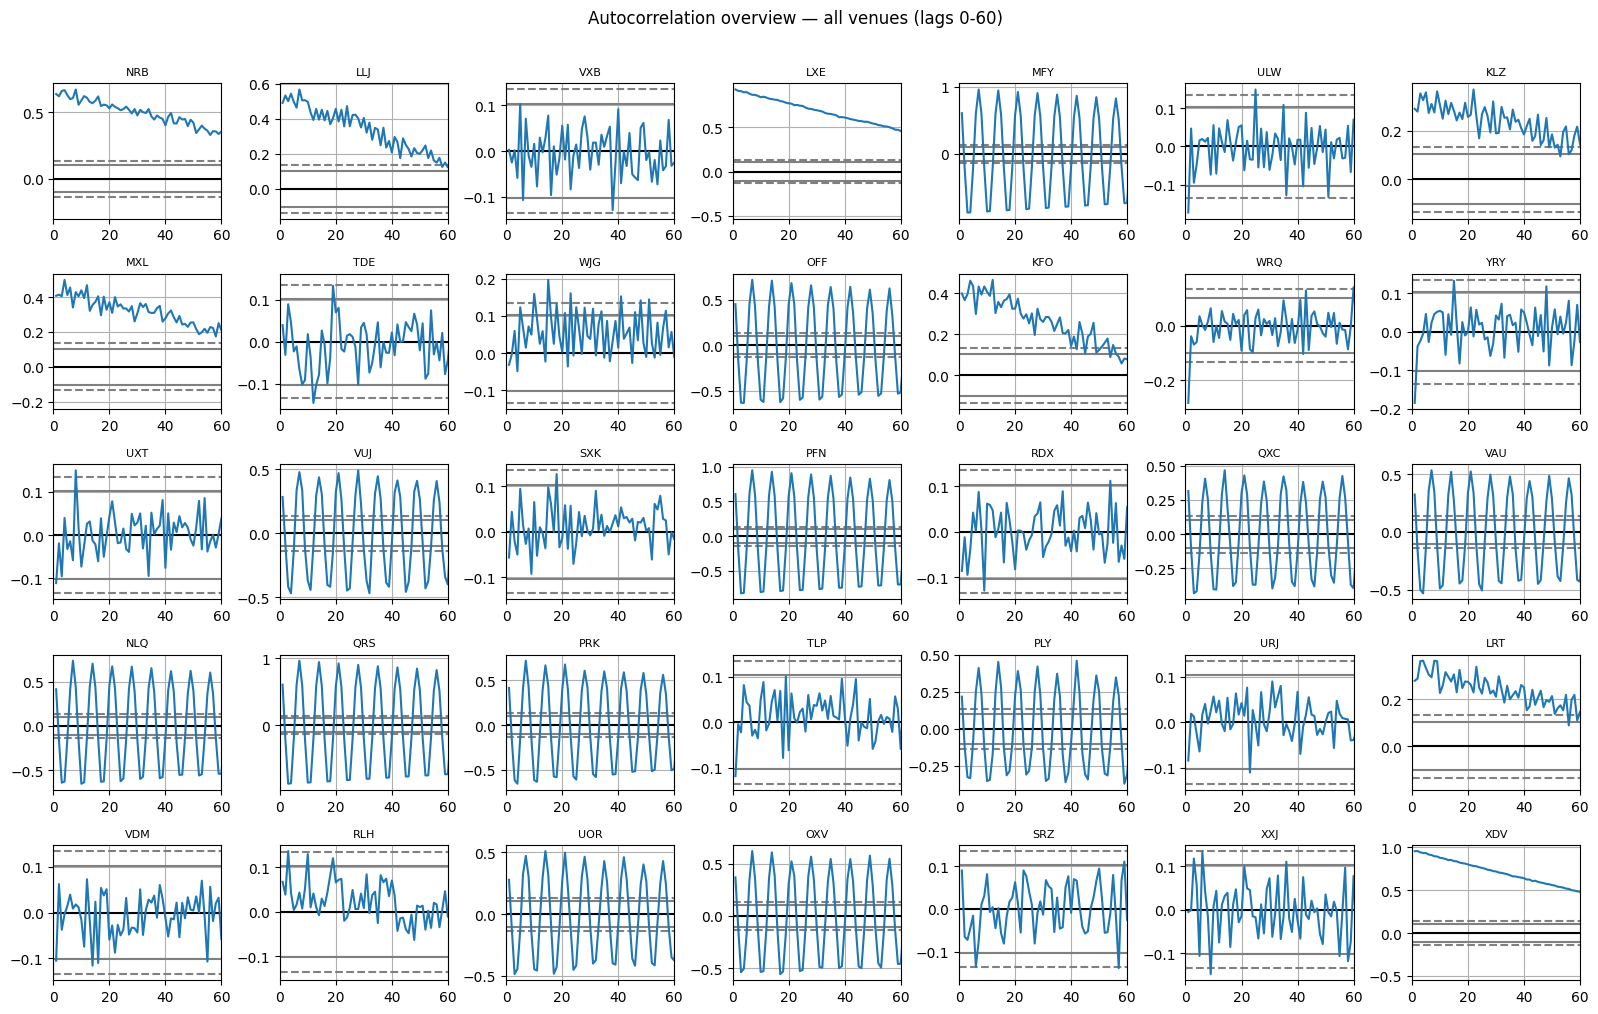

In [ ]:
# Overview grid: all 35 venues (exploratory and used for selection only)
n_cols = 7
row, col = 0, 0
fig0, axes0 = plt.subplots(figsize=(16, 10), nrows=5, ncols=n_cols)
fig0.suptitle("Autocorrelation overview — all venues (lags 0-60)", fontsize=12, y=1.01)

for venue in daily.columns:
    sub = pd.plotting.autocorrelation_plot(daily[venue], axes0[row, col])
    sub.set_title(venue, fontsize=8)
    sub.xaxis.label.set_visible(False)
    sub.yaxis.label.set_visible(False)
    sub.set_xlim([0, 60])
    col += 1
    if col == n_cols:
        row += 1
        col = 0

plt.subplots_adjust(wspace=0.5, hspace=0.6)
plt.tight_layout()
plt.show()

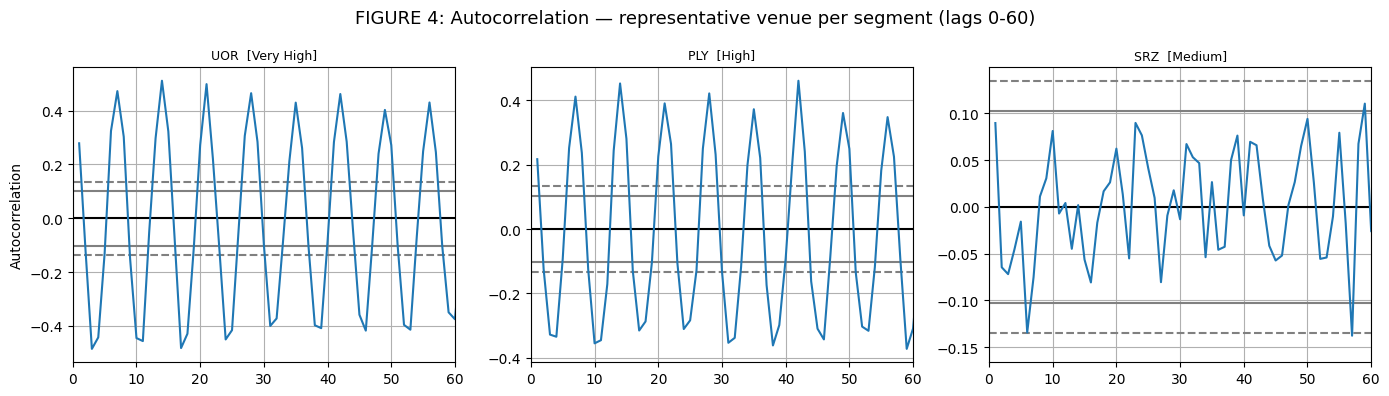

In [ ]:
# One representative per segment (sufficient active data)
selected_auto = []
seen_segs     = []
for v in totals_sorted.index:
    seg = venue_summary_df.loc[v, "VolumeSegment"]
    if seg not in seen_segs and venue_summary_df.loc[v, "ActiveDays"] >= 300:
        selected_auto.append(v)
        seen_segs.append(seg)
    if len(selected_auto) == 4:
        break

n = len(selected_auto)
fig4, axes4 = plt.subplots(1, n, figsize=(14, 4))
fig4.suptitle("FIGURE 4: Autocorrelation — representative venue per segment (lags 0-60)",fontsize=13,)

for i, venue in enumerate(selected_auto):
    seg = venue_summary_df.loc[venue, "VolumeSegment"]
    sub = pd.plotting.autocorrelation_plot(daily[venue], axes4[i])
    sub.set_title(f"{venue}  [{seg}]", fontsize=9)
    sub.set_xlim([0, 60])
    sub.xaxis.label.set_visible(False)
    if i > 0:
        sub.yaxis.label.set_visible(False)

plt.tight_layout()
plt.show()

## Figure 5 — Correlation heatmap of venue attributes

**Lecture examples:** L04 `05HeatMap correlation selected.py`, `12HeatMap summary correlation.py`

Correlation computed on `venue_summary_df` (one row per venue) across visitor-derived metrics and all five venue attribute columns, following the summary heatmap pattern from `12HeatMap summary correlation.py`.

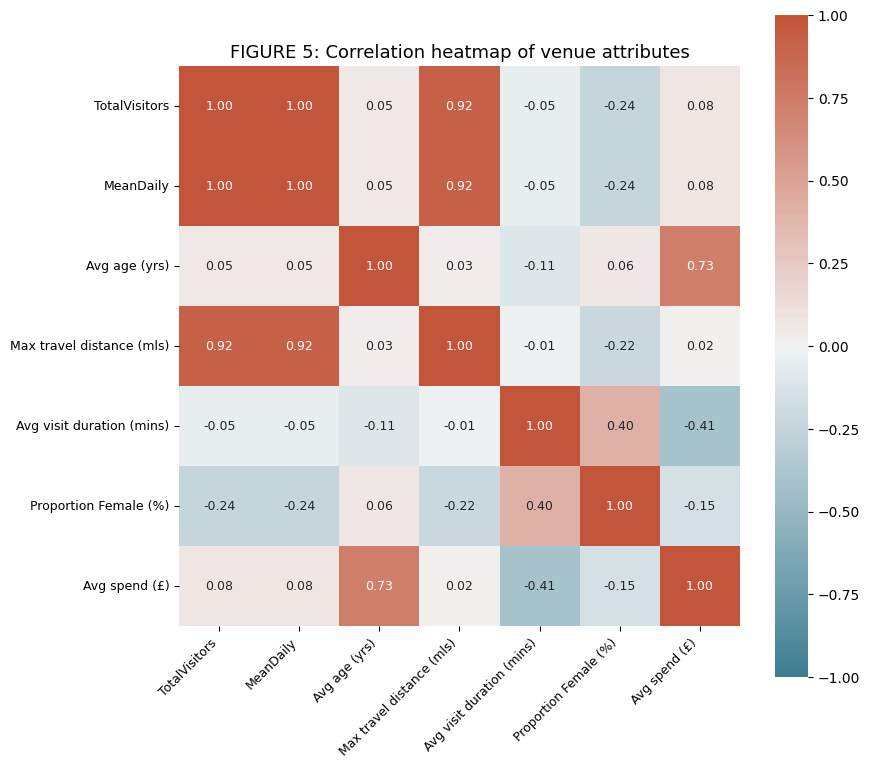

In [ ]:
# Version 1 - Shows attribute correlation
attr_cols = [
    "TotalVisitors",
    "MeanDaily",
    "Avg age (yrs)",
    "Max travel distance (mls)",
    "Avg visit duration (mins)",
    "Proportion Female (%)",
    "Avg spend (£)",
]

plt.figure(figsize=(9, 8))
corr = venue_summary_df[attr_cols].corr()
ax = sns.heatmap(
    corr,
    vmin=-1, vmax=1, center=0,
    cmap=sns.diverging_palette(220, 20, n=200),
    square=True, annot=True, fmt=".2f",
    annot_kws={"size": 9},
)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right", fontsize=9)
ax.set_yticklabels(ax.get_yticklabels(), fontsize=9)
plt.title("FIGURE 5: Correlation heatmap of venue attributes", fontsize=13)
plt.tight_layout()
plt.show()

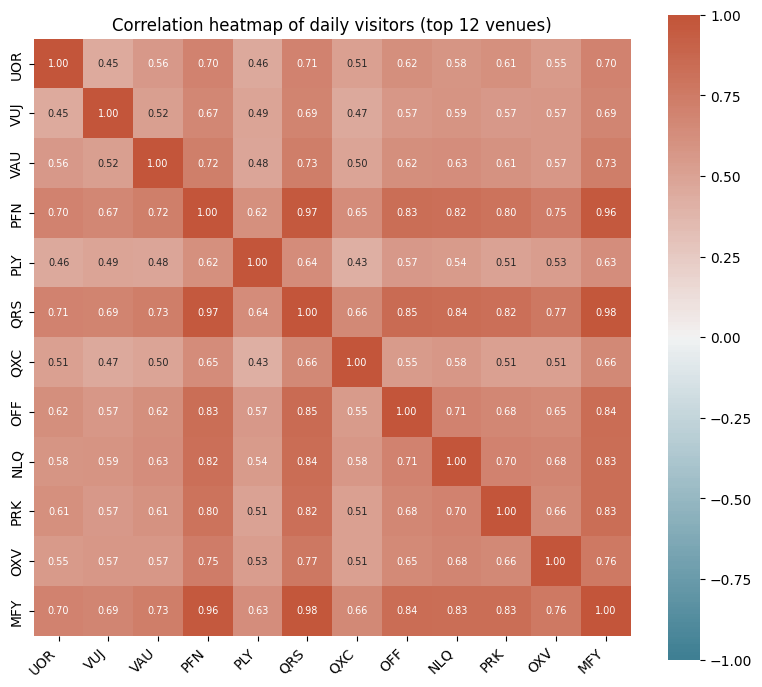

In [ ]:
# Version 2 - Shows time-series correlation (exploratory, not in report)
top12 = list(totals_sorted.index[:12])
corr_sel = visitor_df[top12].corr()

plt.figure(figsize=(8, 7))
ax = sns.heatmap(
    corr_sel, vmin=-1, vmax=1, center=0,
    cmap=sns.diverging_palette(220, 20, n=200),
    square=True, annot=True, fmt=".2f", annot_kws={"size": 7}
)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")
plt.title("Correlation heatmap of daily visitors (top 12 venues)")
plt.tight_layout()
plt.show()

## Figure 6 — Bubble plot: average spend vs average visit duration

**Lecture examples:** L06 `08BubblePlot price cost profit.py`,
`09BubblePlot price cost sales.py`, L04 `14ScatterPlot price vs cost coloured.py`

Bubble size is proportional to total annual visitors. Points are coloured by volume
segment and labelled with venue codes using `plt.annotate()`. Diagonal reference lines
represent constant spend-per-minute rates, following the lecture's reference line pattern.

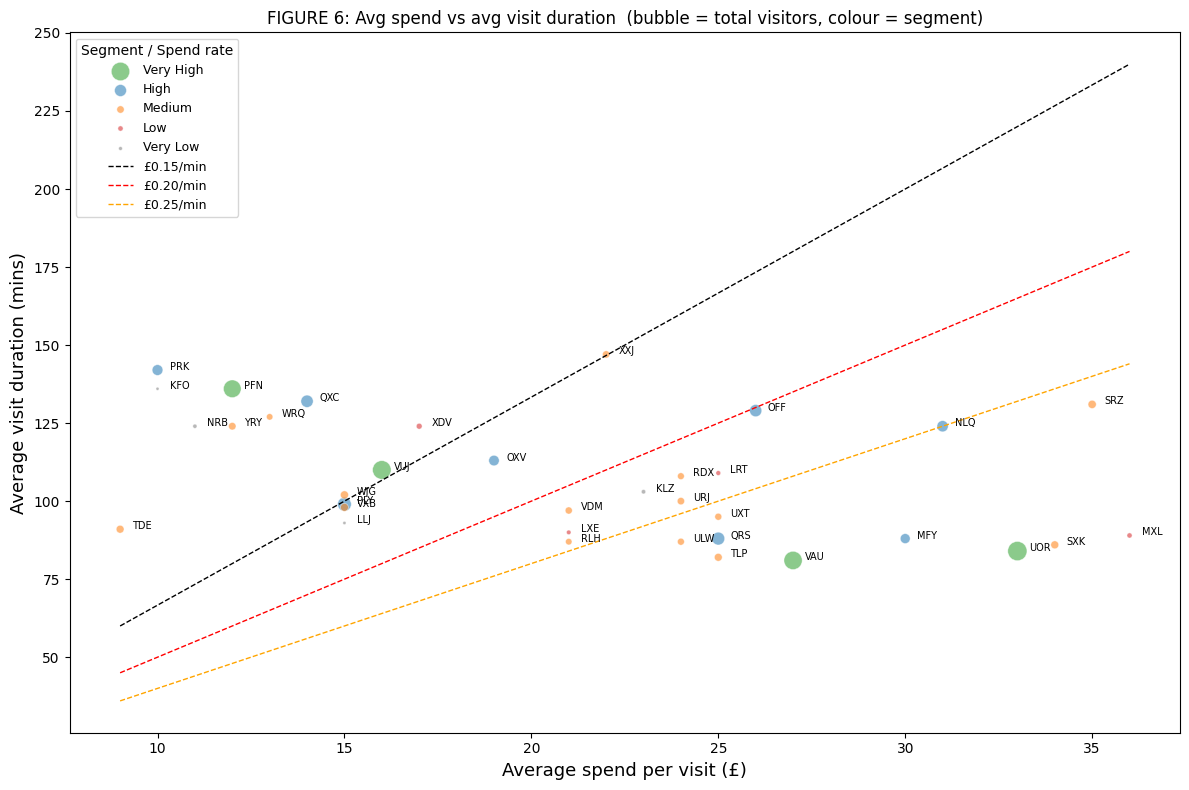

In [ ]:
venue_summary_df["BubbleSize"] = venue_summary_df["TotalVisitors"] * 0.001

x_col = "Avg spend (£)"
y_col = "Avg visit duration (mins)"

plt.figure(figsize=(12, 8))

for seg, colour in seg_colours.items():
    mask   = venue_summary_df["VolumeSegment"] == seg
    subset = venue_summary_df[mask]
    plt.scatter(
        subset[x_col],
        subset[y_col],
        s=subset["BubbleSize"],
        alpha=0.55,
        color=colour,
        label=seg,
        edgecolors="white",
        linewidths=0.5,
    )

xrng = venue_summary_df[x_col].max() - venue_summary_df[x_col].min()
for venue in venue_summary_df.index:
    plt.annotate(
        venue,
        (venue_summary_df.loc[venue, x_col] + xrng * 0.012,
         venue_summary_df.loc[venue, y_col]),
        fontsize=7,
    )

# Diagonal reference lines: spend per minute = constant
# y = x / k  where k = £/min
x_vals = np.linspace(
    venue_summary_df[x_col].min(),
    venue_summary_df[x_col].max(),
    100
)
ref_lines = {
    0.15: ("black",  "£0.15/min"),
    0.20: ("red",    "£0.20/min"),
    0.25: ("orange", "£0.25/min"),
}
for k, (colour, lbl) in ref_lines.items():
    plt.plot(x_vals, x_vals / k, linestyle="--", linewidth=1,
             color=colour, label=lbl)

plt.xlabel("Average spend per visit (£)", fontsize=13)
plt.ylabel("Average visit duration (mins)", fontsize=13)
plt.title("FIGURE 6: Avg spend vs avg visit duration  ""(bubble = total visitors, colour = segment)",fontsize=12,)
plt.legend(title="Segment / Spend rate", loc="upper left", fontsize=9)
plt.tight_layout()
plt.show()

## Figure 7 (Interactive) — Venue time-series explorer

**Lecture basis:** L03 `05LinePlot high volume rolling averaged.py`

Dropdown selects any of the 35 venues; slider adjusts the rolling average window (7, 14, 21 or 28 days). Green/red dashed lines mark first and last active dates where a venue opened or closed during 2023.

**How to use:** Select a venue from the dropdown and adjust the rolling average slider to smooth or reveal detail. Switch to Very Low venues to see lifecycle lines.

In [ ]:
# Pre-compute rolling averages for all four window sizes
roll_cache = {p: daily.rolling(window=p).mean() for p in [7, 14, 21, 28]}

venue_dd = widgets.Dropdown(
    options=sorted(daily.columns.tolist()),
    value=totals_sorted.index[0],
    description="Venue:",
    style={"description_width": "initial"},
)
period_sl = widgets.SelectionSlider(
    options=[7, 14, 21, 28],
    value=7,
    description="Rolling avg (days):",
    style={"description_width": "initial"},
    layout=widgets.Layout(width="320px"),
)
out7 = widgets.Output()

def plot_venue(change=None):
    v    = venue_dd.value
    p    = period_sl.value
    roll = roll_cache[p]
    fa   = venue_summary_df.loc[v, "FirstActive"]
    la   = venue_summary_df.loc[v, "LastActive"]
    seg  = venue_summary_df.loc[v, "VolumeSegment"]
    with out7:
        clear_output(wait=True)
        plt.figure(figsize=(12, 5))
        plt.plot(daily.index, daily[v], linewidth=0.5, label="Daily")
        plt.gca().set_prop_cycle(None)
        plt.plot(roll.index, roll[v], linewidth=2, label=f"{p}-day rolling mean")
        if pd.notna(fa) and venue_summary_df.loc[v, "OpenedDuringPeriod"]:
            plt.axvline(fa, linestyle="--", linewidth=1.2, color="green",
                        label=f"First active: {fa.date()}")
        if pd.notna(la) and venue_summary_df.loc[v, "ClosedDuringPeriod"]:
            plt.axvline(la, linestyle="--", linewidth=1.2, color="red",
                        label=f"Last active: {la.date()}")
        plt.ylim(ymin=0)
        plt.title(f"FIGURE 7: Venue {v} — daily visitors  [{seg} segment]", fontsize=12)
        plt.xlabel("Date", fontsize=11)
        plt.ylabel("Daily visitors", fontsize=11)
        plt.legend(loc="upper left", fontsize=9)
        plt.tight_layout()
        plt.show()

venue_dd.observe(plot_venue,  names="value")
period_sl.observe(plot_venue, names="value")
display(widgets.HBox([venue_dd, period_sl]), out7)
plot_venue()

Output()

## Figure 8 (Interactive) — Venue attribute scatter explorer

**Lecture basis:** L04 `11ScatterPlot marketing vs sales.py`, `14ScatterPlot price vs cost coloured.py`

Two dropdowns select the x and y attributes from `venue_summary_df`. Points are coloured by volume segment and labelled with venue codes. Pearson r is shown in the chart title.

**How to use:** Change either dropdown to explore different attribute pairs. Try Avg spend (x) vs Max travel distance (y), or Avg visit duration (x) vs TotalVisitors (y).

In [ ]:
attr_options = [
    "TotalVisitors",
    "MeanDaily",
    "Avg age (yrs)",
    "Max travel distance (mls)",
    "Avg visit duration (mins)",
    "Proportion Female (%)",
    "Avg spend (£)",
]

x_dd = widgets.Dropdown(options=attr_options, value="Avg spend (£)", description="X-axis:", style={"description_width": "initial"})
y_dd = widgets.Dropdown(options=attr_options, value="Avg age (yrs)",description="Y-axis:", style={"description_width": "initial"})
out8 = widgets.Output()

def plot_scatter(change=None):
    xc = x_dd.value
    yc = y_dd.value
    with out8:
        clear_output(wait=True)
        fig, ax = plt.subplots(figsize=(11, 7))
        for seg, colour in seg_colours.items():
            mask   = venue_summary_df["VolumeSegment"] == seg
            subset = venue_summary_df[mask]
            ax.scatter(subset[xc], subset[yc],
                       color=colour, label=seg,
                       s=70, alpha=0.85, edgecolors="white", linewidths=0.5)
        xrng = venue_summary_df[xc].max() - venue_summary_df[xc].min()
        for venue in venue_summary_df.index:
            ax.annotate(
                venue,
                (venue_summary_df.loc[venue, xc] + xrng * 0.012,
                 venue_summary_df.loc[venue, yc]),
                fontsize=7,
            )
        r = float(np.corrcoef(venue_summary_df[xc], venue_summary_df[yc])[0, 1])
        ax.set_xlabel(xc, fontsize=12)
        ax.set_ylabel(yc, fontsize=12)
        ax.set_title(f"FIGURE 8: {xc}  vs  {yc}   (Pearson r = {r:.2f})", fontsize=12)
        ax.legend(title="Segment", loc="best", fontsize=9)
        plt.tight_layout()
        plt.show()

x_dd.observe(plot_scatter, names="value")
y_dd.observe(plot_scatter, names="value")
display(widgets.HBox([x_dd, y_dd]), out8)
plot_scatter()

Output()

## Additional Summaries
These tables support the conclusions made in the report.

In [ ]:
print("=" * 58)
print("  Venues that OPENED during 2023")
print("=" * 58)
opened_df = (venue_summary_df[venue_summary_df["OpenedDuringPeriod"]]
             .sort_values("FirstActive")
             [["FirstActive", "ActiveDays", "TotalVisitors", "VolumeSegment"]])
print(opened_df.to_string() if len(opened_df) else "  None detected.")

print()
print("=" * 58)
print("  Venues that CLOSED during 2023")
print("=" * 58)
closed_df = (venue_summary_df[venue_summary_df["ClosedDuringPeriod"]]
             .sort_values("LastActive")
             [["LastActive", "ActiveDays", "TotalVisitors", "VolumeSegment"]])
print(closed_df.to_string() if len(closed_df) else "  None detected.")

print()
print("=" * 58)
print("  Top 10 venues by anomaly day count")
print("=" * 58)
anomaly_df = (venue_summary_df
              .sort_values("AnomalyDays", ascending=False)
              .head(10)
              [["AnomalyDays", "TotalVisitors", "VolumeSegment"]])
print(anomaly_df.to_string())

  Venues that OPENED during 2023
      FirstActive  ActiveDays  TotalVisitors VolumeSegment
Venue                                                     
MXL    2023-04-01         225          13708           Low
LRT    2023-04-01         214          11806           Low
NRB    2023-07-01         164           8989      Very Low
KLZ    2023-07-02         121           9719      Very Low
LLJ    2023-10-01          73           5281      Very Low
KFO    2023-10-01          64           4948      Very Low

  Venues that CLOSED during 2023
      LastActive  ActiveDays  TotalVisitors VolumeSegment
Venue                                                    
LXE   2023-06-30         181          10546           Low
XDV   2023-06-30         181          17473           Low

  Top 10 venues by anomaly day count
       AnomalyDays  TotalVisitors VolumeSegment
Venue                                          
KFO             11           4948      Very Low
KLZ             10           9719      Very Low